In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import glob

In [2]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')

In [3]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis', 'energy_data')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'energy')

In [4]:
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

In [5]:
# files for whole training
step_files = [f for f in data_files if "steps" in f]

In [6]:
print(f"Number of training files: {len(step_files)}")

Number of training files: 18


In [7]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split("_cc")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

In [8]:
def bar_plot_per_mode(data_onfly, data_preload, col_to_plot):
    fig, ax = plt.subplots(figsize=(5, 3))

    label_locs = np.arange(len(batch_sizes))  # the label locations
    width = 0.25  # the width of the bars


    bar_time_data = {"on-the-fly": data_onfly.groupby(["batch_size"])[col_to_plot].mean(),
                    "before training": data_preload.groupby(["batch_size"])[col_to_plot].mean()
                    } # {mode: [mean 32, mean 64, mean 128]}

    multiplier = 0

    for attribute, measurement in bar_time_data.items():
        offset = multiplier*width + multiplier*0.05
        rects = ax.bar(label_locs + offset, measurement, width, label=attribute)
        multiplier += 1

    ax.set_xticks(label_locs + width/2 + 0.025, batch_sizes)
    return fig, ax

Create a dataframe containing all data per training executed.

In [9]:
data_dict = {} # (mode, batch size): concatenated df with all info about all runs
for file in step_files:
    batch_size, num_workers, total_samples, mode = get_params_from_filename(file)
    df = pd.read_csv(file)
    
    # remove first and last data point
    df = df.iloc[1:-1]
    
    # only keep relevant columns
    df = df[[
            "duration", 
             "emissions", 
             "cpu_power", 
             "gpu_power", 
             "ram_power", 
             "cpu_energy", 
             "gpu_energy", 
             "ram_energy", 
             "energy_consumed"]]

    if (mode, batch_size) not in data_dict:
        data_dict[(mode, batch_size)] = df

    else:
        # concatenate data to end of df
        data_dict[(mode, batch_size)] = pd.concat([data_dict[(mode, batch_size)], df])

In [10]:
data_dict[("onfly", 32)].mean().to_frame().T

,duration,emissions,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed
0,1.58655,8.806677e-07,360.0,137.790191,10.0,0.000159,0.000061,0.000004,0.000224


In [11]:
# get the averages for each column
data_cc_onfly = pd.DataFrame()
data_cc_preload = pd.DataFrame()

for m in modes:
    for b in batch_sizes:
        d_avg = pd.DataFrame()
        d = data_dict[(m, b)]

        # take the mean of the power
        for col in ["gpu_power", "cpu_power", "ram_power"]:
            d_avg[col] = [d[col].mean()]

        # take the sum of the emissions and energy
        for col in ["duration", "emissions", "cpu_energy", "gpu_energy", "ram_energy", "energy_consumed"]:
            d_avg[col] = [d[col].sum()]

        # add batch size and mode
        d_avg["batch_size"] = [b]
        d_avg["mode"] = [m]

        if m == "onfly":
            data_cc_onfly = pd.concat([data_cc_onfly, d_avg])
        else:
            data_cc_preload = pd.concat([data_cc_preload, d_avg])

In [12]:
data_cc_onfly

,gpu_power,cpu_power,ram_power,duration,emissions,cpu_energy,gpu_energy,ram_energy,energy_consumed,batch_size,mode
0,137.790191,360.0,10.0,514.042261,0.000285,0.051379,0.019663,0.001427,0.072469,32,onfly
0,134.139532,360.0,10.0,500.554210,0.000276,0.050036,0.018644,0.001390,0.070070,64,onfly
0,127.948534,360.0,10.0,486.159748,0.000265,0.048601,0.017274,0.001350,0.067225,128,onfly


CO2 emissions

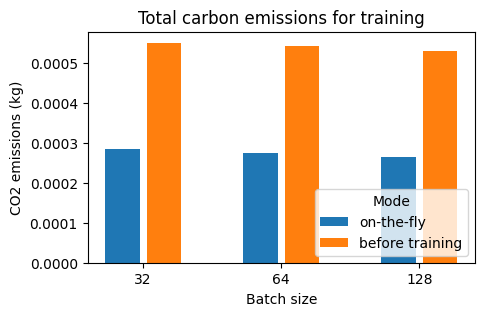

In [13]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="emissions")

ax.set_xlabel("Batch size")
ax.set_title(f"Total carbon emissions for training")
ax.set_ylabel("CO2 emissions (kg)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "carbon_emissions_train_avg.png"), dpi=300, bbox_inches="tight")

GPU, CPU, RAM power -- these are all averaged

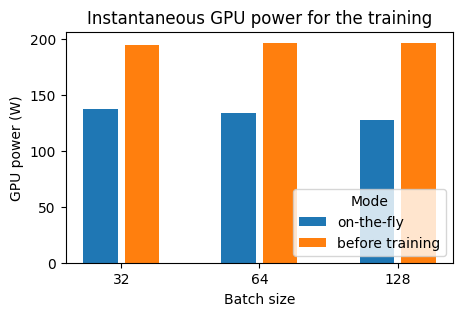

In [14]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="gpu_power")

ax.set_xlabel("Batch size")
ax.set_title(f"Instantaneous GPU power for the training")
ax.set_ylabel("GPU power (W)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "gpu_power_train_avg.png"), dpi=300, bbox_inches="tight")

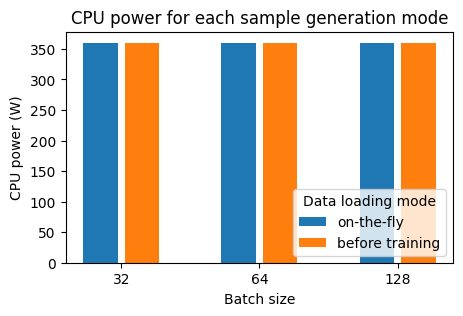

In [15]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="cpu_power")

ax.set_xlabel("Batch size")
ax.set_title(f"CPU power for each sample generation mode")
ax.set_ylabel("CPU power (W)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "cpu_power_train_avg.png"), dpi=300, bbox_inches="tight")

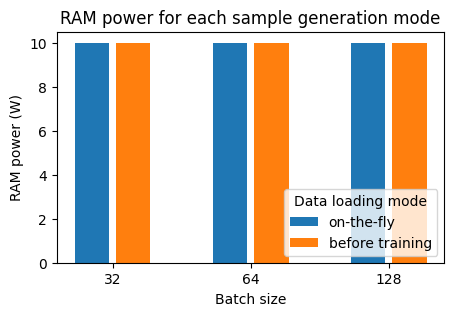

In [16]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="ram_power")

ax.set_xlabel("Batch size")
ax.set_title(f"RAM power for each sample generation mode")
ax.set_ylabel("RAM power (W)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "ram_power_train_avg.png"), dpi=300, bbox_inches="tight")

Energy

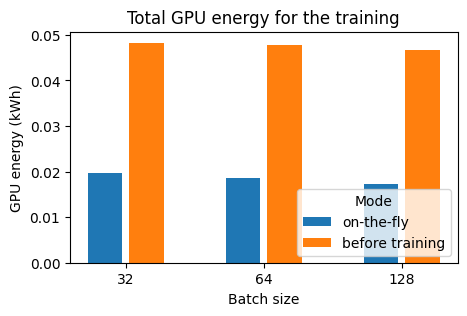

In [17]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="gpu_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"Total GPU energy for the training")
ax.set_ylabel("GPU energy (kWh)")
ax.legend(title="Mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "gpu_energy_train_avg.png"), dpi=300, bbox_inches="tight")

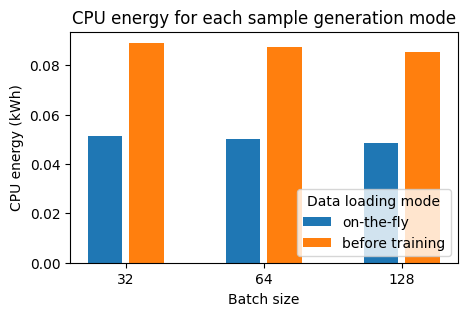

In [18]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="cpu_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"CPU energy for each sample generation mode")
ax.set_ylabel("CPU energy (kWh)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "cpu_energy_train_avg.png"), dpi=300, bbox_inches="tight")

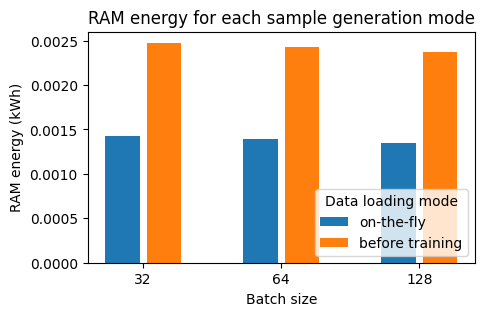

In [19]:
fig, ax = bar_plot_per_mode(data_cc_onfly, data_cc_preload, col_to_plot="ram_energy")

ax.set_xlabel("Batch size")
ax.set_title(f"RAM energy for each sample generation mode")
ax.set_ylabel("RAM energy (kWh)")
ax.legend(title="Data loading mode", loc="lower right")
fig.savefig(os.path.join(plot_dir,  "ram_energy_train_avg.png"), dpi=300, bbox_inches="tight")